# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


In [25]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import missingno as msno


In [26]:
# =========================================================
# PATH CONFIGURATION
# =========================================================

ROOT = Path.cwd()

WEATHER_FILE   = ROOT / 'wetter.csv'
SALES_FILE     = ROOT / 'umsatzdaten_gekuerzt.csv'
KIWO_FILE      = ROOT / 'kiwo.csv'
FERIEN_FILE    = ROOT / 'Ferien_SH.csv'
FEIERTAGE_FILE = ROOT / 'Feiertage_holidays_sh_2013_2019.csv'

In [27]:
# =========================================================
# HELPER FUNCTIONS
# =========================================================

def find_date_column(df):
    candidates = ['date', 'datum', 'Datum', 'DATUM']
    for c in df.columns:
        if c.lower() in [x.lower() for x in candidates]:
            return c
    return None


def read_and_normalize(path):
    df = pd.read_csv(path)
    date_col = find_date_column(df)
    if date_col is None:
        raise ValueError(f'No date column in {path}')
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.rename(columns={date_col: 'date'})
    return df


def find_column(df, keywords):
    keywords = [k.lower() for k in keywords]
    for c in df.columns:
        if any(k in c.lower() for k in keywords):
            return c
    return None


def wg6_is_available(d):
    if pd.isna(d):
        return False
    return d.month in [11, 12]

## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [28]:
# Load the data (sales data as the primary dataset)
df = read_and_normalize(SALES_FILE)

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head())



Number of samples: 9334
Number of features: 4
Example data:
        id       date  Warengruppe      Umsatz
0  1307011 2013-07-01            1  148.828353
1  1307021 2013-07-02            1  159.793757
2  1307031 2013-07-03            1  111.885594
3  1307041 2013-07-04            1  168.864941
4  1307051 2013-07-05            1  171.280754


## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


Missing values per column:
id             0
date           0
Warengruppe    0
Umsatz         0
dtype: int64


<Figure size 1400x600 with 0 Axes>

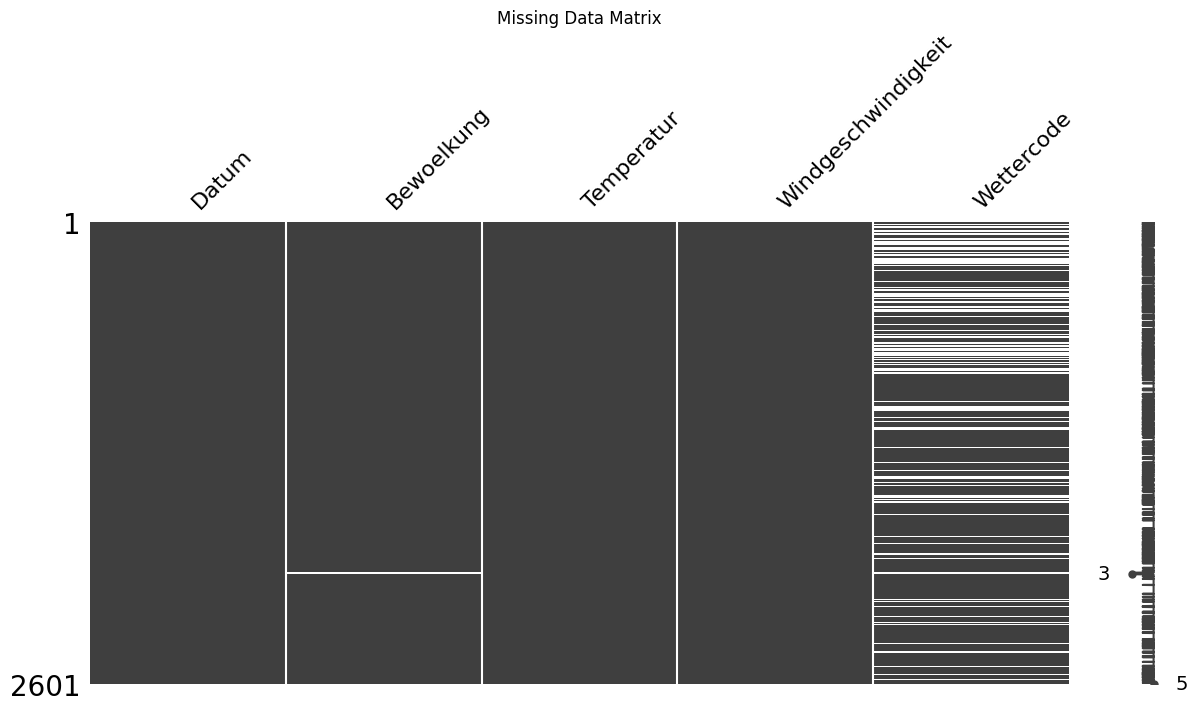

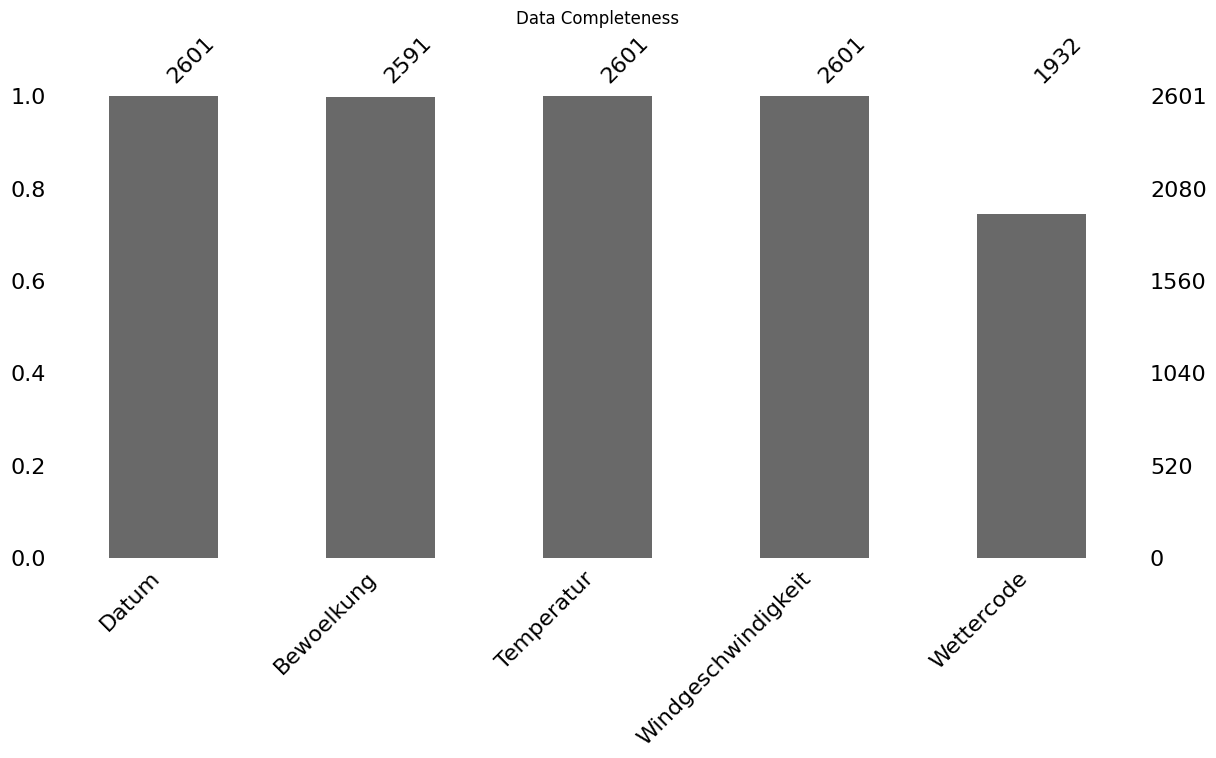

In [29]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Visualize missing data
df = pd.read_csv(WEATHER_FILE)

plt.figure(figsize=(14, 6))
msno.matrix(df, figsize=(14, 6))
plt.title("Missing Data Matrix")
plt.show()

plt.figure(figsize=(14, 6))
msno.bar(df, figsize=(14, 6))
plt.title("Data Completeness")
plt.show()

In [30]:
# Handling missing values

# =========================================================
# STEP 1 — WEATHER IMPUTATION
# =========================================================
# Missing weather values are handled via time-based interpolation
# (linear for Temperatur/Windgeschwindigkeit, rounded for Bewoelkung,
#  forward-/back-fill for the categorical Wettercode).

print('STEP 1: WEATHER IMPUTATION')

weather = read_and_normalize(WEATHER_FILE)

calendar = pd.DataFrame({
    'date': pd.date_range(weather['date'].min(), weather['date'].max(), freq='D')
})

weather = calendar.merge(weather, on='date', how='left')

numeric_cols = ['Bewoelkung', 'Temperatur', 'Windgeschwindigkeit', 'Wettercode']
for col in numeric_cols:
    if col in weather.columns:
        weather[col] = pd.to_numeric(weather[col], errors='coerce')

weather = weather.sort_values('date').set_index('date')

if 'Temperatur' in weather.columns:
    weather['Temperatur'] = weather['Temperatur'].interpolate(
        method='time', limit_direction='both'
    )

if 'Windgeschwindigkeit' in weather.columns:
    weather['Windgeschwindigkeit'] = weather['Windgeschwindigkeit'].interpolate(
        method='time', limit_direction='both'
    )

if 'Bewoelkung' in weather.columns:
    weather['Bewoelkung'] = (
        weather['Bewoelkung']
        .interpolate(method='time', limit_direction='both')
        .round().clip(0, 8)
    )

if 'Wettercode' in weather.columns:
    weather['Wettercode'] = weather['Wettercode'].ffill().bfill()

weather = weather.reset_index()
weather.to_csv('wetter_imputed.csv', index=False)
print('Saved wetter_imputed.csv')

# Check remaining missing values after imputation
print('\nMissing values after imputation:')
print(weather.isnull().sum())

STEP 1: WEATHER IMPUTATION
Saved wetter_imputed.csv

Missing values after imputation:
date                   0
Bewoelkung             0
Temperatur             0
Windgeschwindigkeit    0
Wettercode             0
dtype: int64


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


In [43]:
# =========================================================
# STEP 2 — CALENDAR FEATURE EXPANSION
# =========================================================

def expand_calendar(df, name):
    date_col = find_date_column(df)
    ind_col  = find_column(df, [name])
    if ind_col is None or ind_col == date_col:
        df[name] = 1
        ind_col  = name
    df = df[[date_col, ind_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    cal = pd.DataFrame({
        date_col: pd.date_range(df[date_col].min(), df[date_col].max(), freq='D')
    })
    df = cal.merge(df, on=date_col, how='left')
    df[ind_col] = df[ind_col].fillna(0).astype(int)
    df = df.rename(columns={date_col: 'date', ind_col: name})
    df.to_csv(f'{name}_expanded.csv', index=False)
    return df


kiwo      = expand_calendar(pd.read_csv(KIWO_FILE),      'KielerWoche')
ferien    = expand_calendar(pd.read_csv(FERIEN_FILE),    'school_holiday')
feiertage = expand_calendar(pd.read_csv(FEIERTAGE_FILE), 'public_holiday')


In [35]:
# =========================================================
# STEP 3 — MERGE SALES + FEATURES
# =========================================================

print('STEP 3: MERGING DATASETS')

sales = read_and_normalize(SALES_FILE)
sales['Warengruppe'] = pd.to_numeric(sales['Warengruppe'], errors='coerce')
sales['id']          = pd.to_numeric(sales['id'],          errors='coerce')
sales['Umsatz']      = pd.to_numeric(sales['Umsatz'],      errors='coerce')

start = min(weather['date'].min(), sales['date'].min())
end   = max(weather['date'].max(), sales['date'].max())

calendar = pd.DataFrame({'date': pd.date_range(start, end, freq='D')})

base = (
    calendar
    .merge(weather,   on='date', how='left')
    .merge(kiwo,      on='date', how='left')
    .merge(ferien,    on='date', how='left')
    .merge(feiertage, on='date', how='left')
)

warengruppen = [1, 2, 3, 4, 5]
rows = []
for d in calendar['date']:
    for wg in warengruppen:
        rows.append((d, wg))
    if wg6_is_available(d):
        rows.append((d, 6))

grid = pd.DataFrame(rows, columns=['date', 'Warengruppe'])
grid['id'] = (
    grid['date'].dt.strftime('%y%m%d').astype(int) * 10
    + grid['Warengruppe']
)

merged = grid.merge(sales, on=['date', 'Warengruppe', 'id'], how='left')
merged = merged.merge(base, on='date', how='left')
merged.to_csv('merged_expanded_data_fullcalendar.csv', index=False)
print('Saved merged_expanded_data_fullcalendar.csv')

# Display structure of the merged dataset
print(f'\nMerged dataset — samples: {merged.shape[0]}, features: {merged.shape[1]}')
merged.head()

STEP 3: MERGING DATASETS
Saved merged_expanded_data_fullcalendar.csv

Merged dataset — samples: 14277, features: 11


,date,Warengruppe,id,Umsatz,Bewoelkung,Temperatur,Windgeschwindigkeit,Wettercode,KielerWoche,school_holiday,public_holiday
0,2012-01-01,1,1201011,NaN,8.0,9.825,14.0,58.0,NaN,NaN,NaN
1,2012-01-01,2,1201012,NaN,8.0,9.825,14.0,58.0,NaN,NaN,NaN
2,2012-01-01,3,1201013,NaN,8.0,9.825,14.0,58.0,NaN,NaN,NaN
3,2012-01-01,4,1201014,NaN,8.0,9.825,14.0,58.0,NaN,NaN,NaN
4,2012-01-01,5,1201015,NaN,8.0,9.825,14.0,58.0,NaN,NaN,NaN


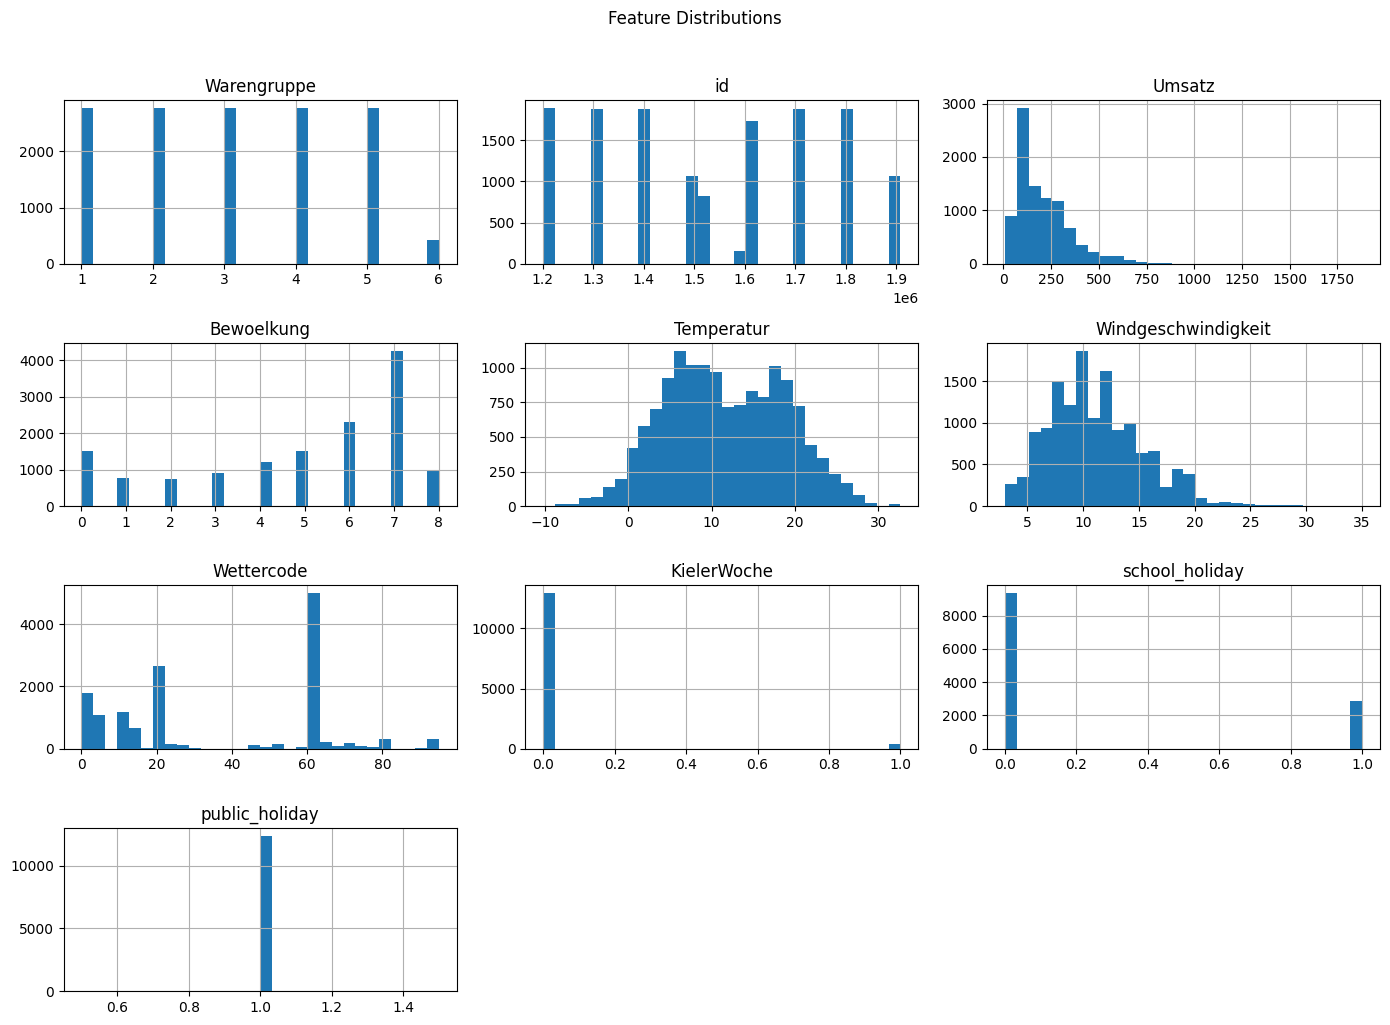

In [36]:
# Plotting histograms of all numerical features in the merged dataset
merged.select_dtypes(include='number').hist(figsize=(14, 10), bins=30)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


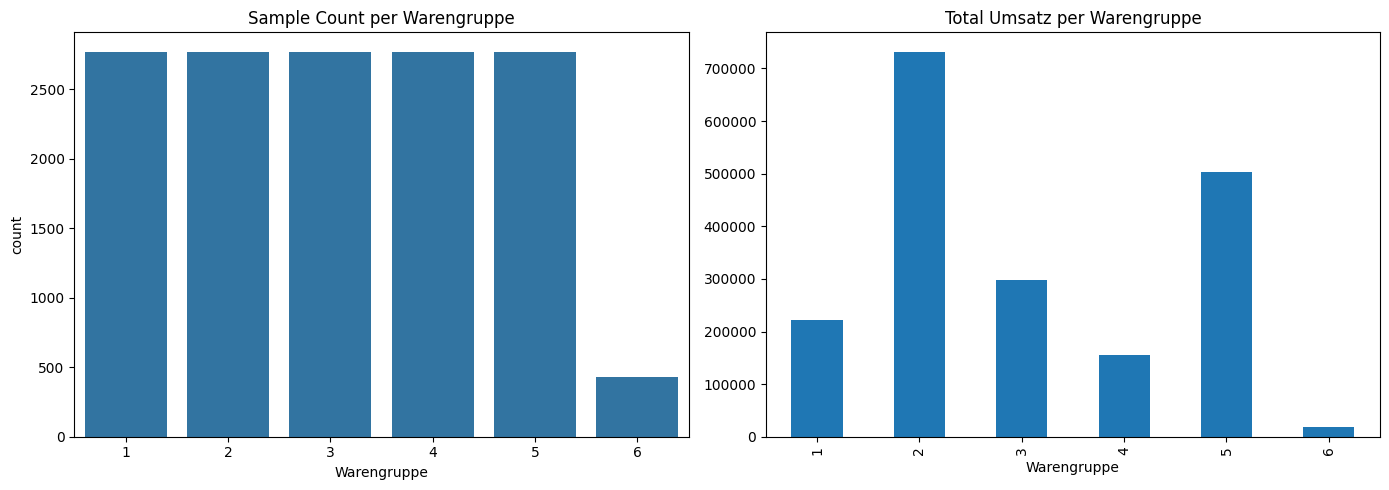

In [38]:
'''
Check distribution across Warengruppen (product groups)
Warengruppe 6 is only available in November/December - this seasonal
availability constitutes a structural imbalance to be aware of.
'''

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Warengruppe', data=merged, ax=axes[0])
axes[0].set_title('Sample Count per Warengruppe')
wg_sales = merged.groupby('Warengruppe')['Umsatz'].sum()
wg_sales.plot(kind='bar', ax=axes[1])
axes[1].set_title('Total Umsatz per Warengruppe')
axes[1].set_xlabel('Warengruppe')
plt.tight_layout()
plt.show()

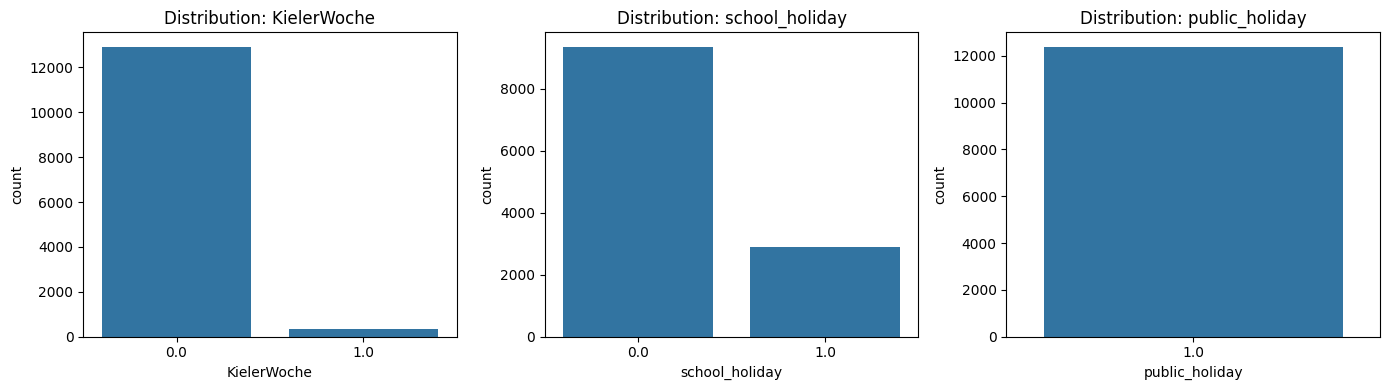

In [39]:
# Check calendar feature balance (KielerWoche, school holidays, public holidays)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['KielerWoche', 'school_holiday', 'public_holiday']):
    if col in merged.columns:
        sns.countplot(x=col, data=merged, ax=ax)
        ax.set_title(f'Distribution: {col}')

plt.tight_layout()
plt.show()


## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


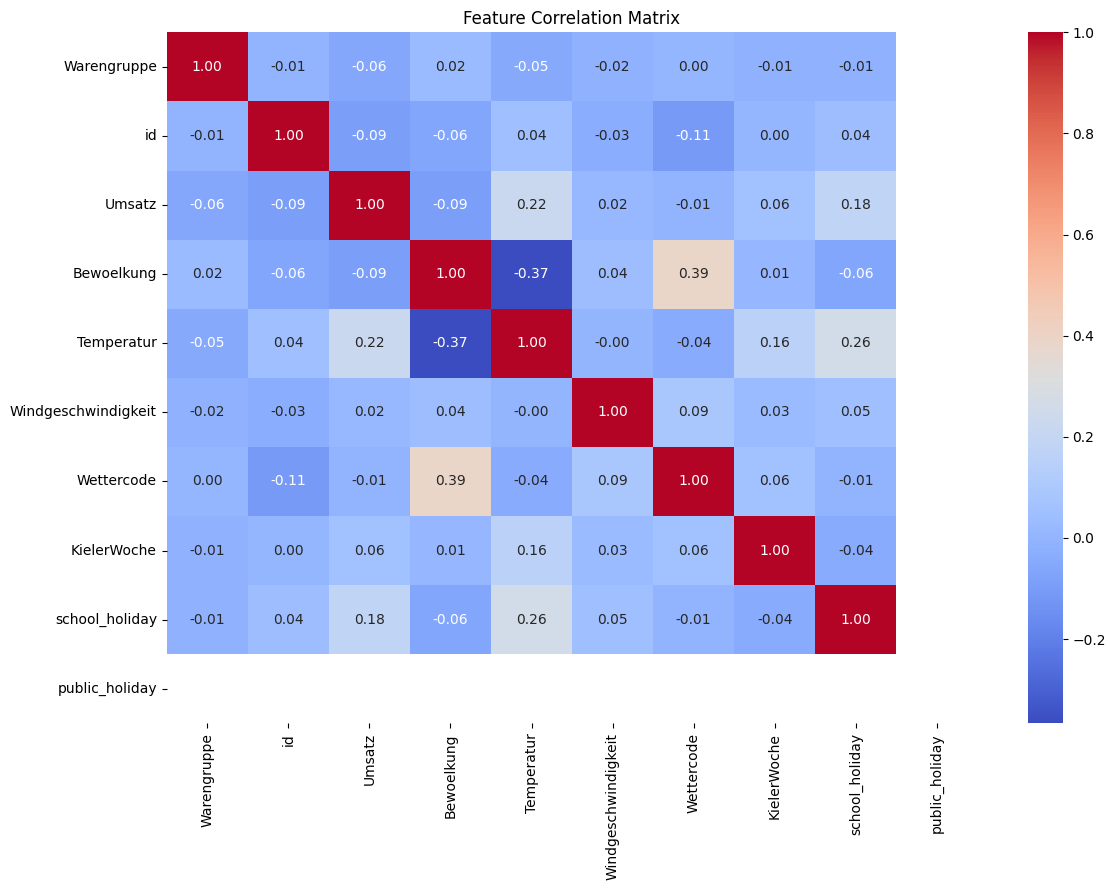

In [40]:
# Plotting a heatmap to show feature correlations
correlation_matrix = merged.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [42]:
# =========================================================
# STEP 4 — TRAIN / VALIDATION / TEST SPLIT
# =========================================================

print('STEP 4: TRAIN / VAL / TEST SPLIT')

df = pd.read_csv('merged_expanded_data_fullcalendar.csv', parse_dates=['date'])

train = df[
    (df['date'] >= '2013-07-01') & (df['date'] <= '2017-07-31')
].dropna(subset=['Umsatz'])

val = df[
    (df['date'] >= '2017-08-01') & (df['date'] <= '2018-07-31')
].dropna(subset=['Umsatz'])

test = df[
    (df['date'] >= '2018-08-01') & (df['date'] <= '2019-07-31')
]

train.to_csv('train_split.csv', index=False)
val.to_csv('val_split.csv',     index=False)
test.to_csv('test_split.csv',   index=False)

print(f'Train samples : {len(train)}')
print(f'Val   samples : {len(val)}')
print(f'Test  samples : {len(test)}')

print('\nFINAL OUTPUT FILES CREATED:')
for f in [
    'wetter_imputed.csv',
    'KielerWoche_expanded.csv',
    'school_holiday_expanded.csv',
    'public_holiday_expanded.csv',
    'merged_expanded_data_fullcalendar.csv',
    'train_split.csv', 'val_split.csv', 'test_split.csv'
]:
    print(f'  {f}')

print('\nPIPELINE COMPLETE')

STEP 4: TRAIN / VAL / TEST SPLIT
Train samples : 7475
Val   samples : 1840
Test  samples : 1886

FINAL OUTPUT FILES CREATED:
  wetter_imputed.csv
  KielerWoche_expanded.csv
  school_holiday_expanded.csv
  public_holiday_expanded.csv
  merged_expanded_data_fullcalendar.csv
  train_split.csv
  val_split.csv
  test_split.csv

PIPELINE COMPLETE
